In [ ]:
# %pip install -U pylibcudf-cu12
# %pip install -U cudf-cu12
# %pip install -U google-cloud-bigquery==3.31.0
# %pip install -U bigframes
# %pip install google-api-core==2.15.0
# %pip install rich==13.9.2
# %pip install google-cloud-bigquery-storage==2.31.0
# %pip install pyarrow==21.0.0

# %pip install -upgrade

In [ ]:
!pip check

In [ ]:

%pip install pylibcudf-cu12==25.6.0

%pip install pydantic==2.11.10

In [ ]:
%pip install -U bitsandbytes

In [ ]:
%pip install -U transformers

## Local Inference on GPU 
Model page: https://huggingface.co/vignesha7/DeepSeek-R1-Distill-Llama-8B-Medical-Expert

⚠️ If the generated code snippets do not work, please open an issue on either the [model repo](https://huggingface.co/vignesha7/DeepSeek-R1-Distill-Llama-8B-Medical-Expert)
			and/or on [huggingface.js](https://github.com/huggingface/huggingface.js/blob/main/packages/tasks/src/model-libraries-snippets.ts) 🙏

The model you are trying to use is gated. Please make sure you have access to it by visiting the model page.To run inference, either set HF_TOKEN in your environment variables/ Secrets or run the following cell to login. 🤗

In [ ]:
from huggingface_hub import login
login() #No secret to GitHub

In [ ]:
# # # Use a pipeline as a high-level helper
from transformers import pipeline

qa_pipe = pipeline("text-generation", 
                model="vignesha7/DeepSeek-R1-Distill-Llama-8B-Medical-Expert",
               load_in_4bit=True)

In [3]:
# Load model directly
from transformers import AutoTokenizer, AutoModelForCausalLM
model_name = "vignesha7/DeepSeek-R1-Distill-Llama-8B-Medical-Expert"
qa_tokenizer =    AutoTokenizer.from_pretrained(model_name)
qa_model = AutoModelForCausalLM.from_pretrained(model_name)

In [1]:
import torch

In [2]:
from diffusers import StableDiffusionPipeline

pipe = StableDiffusionPipeline.from_pretrained("stabilityai/sd-turbo", torch_dtype=torch.float16, variant="fp16")
pipe.to("cuda")

2025-10-29 02:28:52.295005: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761704932.706568      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761704932.828382      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


model_index.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/618 [00:00<?, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

unet/diffusion_pytorch_model.fp16.safete(…):   0%|          | 0.00/1.73G [00:00<?, ?B/s]

vae/diffusion_pytorch_model.fp16.safeten(…):   0%|          | 0.00/167M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


StableDiffusionPipeline {
  "_class_name": "StableDiffusionPipeline",
  "_diffusers_version": "0.34.0",
  "_name_or_path": "stabilityai/sd-turbo",
  "feature_extractor": [
    null,
    null
  ],
  "image_encoder": [
    null,
    null
  ],
  "requires_safety_checker": true,
  "safety_checker": [
    null,
    null
  ],
  "scheduler": [
    "diffusers",
    "EulerDiscreteScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

In [8]:
def get_answer(question:str):
    input_ids = qa_tokenizer(question, return_tensors="pt").input_ids.to(qa_model.device)
    # Generate continuation
    gen_ids = qa_model.generate(input_ids, max_new_tokens=200)
    
    # Decode all tokens
    answer = qa_tokenizer.decode(gen_ids[0], skip_special_tokens=True)
    return answer

In [14]:
# question = "What does the anatomy of the human heart look like?"
question = 'What is Uremia?'
answer = get_answer(question)
image = pipe(prompt=f'Generate a photo-realistic image for: {answer}', num_inference_steps=1, guidance_scale=0.0).images[0]
# print(answer)

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: [", if someone is experiencing these symptoms, it's important to seek medical attention because uremia is a serious condition that requires treatment. the treatment usually involves addressing the underlying cause, such as kidney disease, and may include dialysis or other forms of treatment. in summary, uremia is a serious condition that requires immediate medical attention. symptoms like fatigue, nausea, vomiting, and muscle cramps are indicative of uremia and should be addressed by a healthcare professional. </ think > uremia is a condition characterized by the accumulation of waste products in the blood due to impaired kidney function. these waste products include urea, potassium, and other substances that the kidneys normally filter out. when the kidneys are not"]


  0%|          | 0/1 [00:00<?, ?it/s]

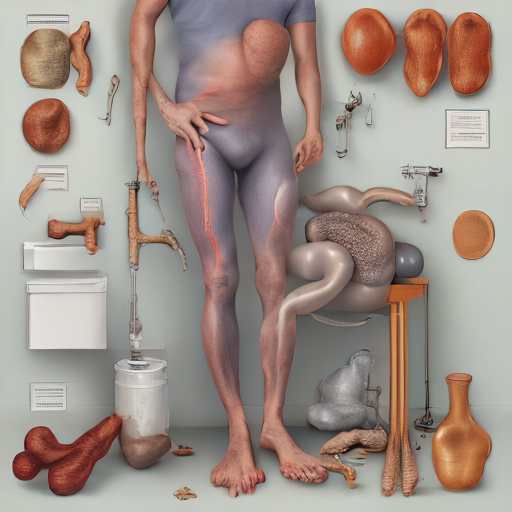

What is Uremia? It's a condition where the kidneys are not working properly and there is an accumulation of waste products in the blood. This can lead to symptoms such as fatigue, nausea, vomiting, and muscle cramps. In severe cases, uremia can also cause more serious conditions like coma or even death.

So, if someone is experiencing these symptoms, it's important to seek medical attention because uremia is a serious condition that requires treatment. The treatment usually involves addressing the underlying cause, such as kidney disease, and may include dialysis or other forms of treatment.

In summary, uremia is a serious condition that requires immediate medical attention. Symptoms like fatigue, nausea, vomiting, and muscle cramps are indicative of uremia and should be addressed by a healthcare professional.
</think>
Uremia is a condition characterized by the accumulation of waste products in the blood due to impaired kidney function. These waste products include urea, potassium, and other substances that the kidneys normally filter out. When the kidneys are not

In [15]:
from IPython.display import display, Markdown, Image

display(image)
display(Markdown(answer))

In [11]:
from transformers import T5Tokenizer, T5ForConditionalGeneration

t5_tokenizer = T5Tokenizer.from_pretrained("t5-base")
t5_model = T5ForConditionalGeneration.from_pretrained("t5-base")

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


In [16]:
input_ids = t5_tokenizer(
    f'summarize: {answer}', return_tensors="pt"
).input_ids  # Batch size 1
# decoder_input_ids = tokenizer("Summarize:", return_tensors="pt").input_ids  # Batch size 1
output = t5_model.generate(input_ids, max_length=70, num_beams=5, temperature=0.7, top_p=0.9, do_sample=True)
summarized = t5_tokenizer.decode(output[0], skip_special_tokens=True)



  0%|          | 0/1 [00:00<?, ?it/s]

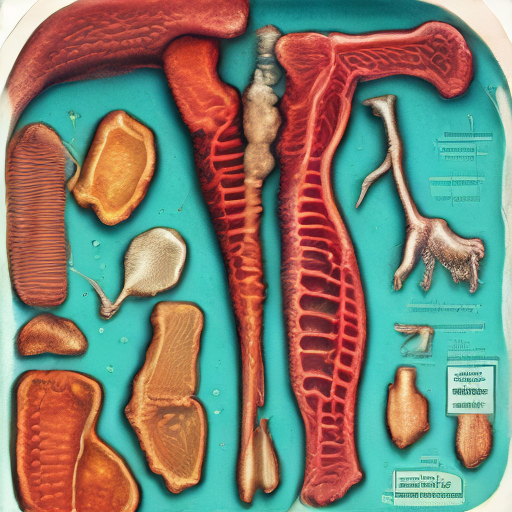

NameError: name 'Markdown' is not defined

In [3]:
image = pipe(prompt=f'A detailed medical illustration showing the effects of uremia — the kidneys failing to filter waste products, leading to the buildup of toxins in the blood. Depict a human body cross-section with highlighted kidneys. Use realistic medical style, clean labels, soft colors, and clear anatomical accuracy, suitable for an educational textbook.', num_inference_steps=1, guidance_scale=0.0).images[0]
display(image)
display(Markdown(summarized))